In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
from pathlib import Path
import numpy as np
import pandas as pd

import mphsweepkit.process_derive as derive
from mphsweepkit.meta_tex import *
from mphsweepkit.process_data import DataPlot, PlotSettings, PlotTextOverrides
from mphsweepkit.process_fields import plot_row_of_fields, plot_grid_of_fields
from mphsweepkit.process_helpers import (
    read_fields_on_geometry,
    get_geometry_idx_from_filter,
    get_internal_idx_from_filters,
    scale_field_columns,
    get_list_of_col_names,
    get_geom_param_from_idx
)

### Load Results

In [28]:
# 1) Load result data exported by CascadedSweepModel.save_result_data(...)
result_dir = Path("global_data")  # adjust if needed
dp = DataPlot.from_result_folder(result_dir)

# 2) Inspect loaded data
print("Input shape:", dp.input_df.shape)
print("Output shape:", dp.output_df.shape)
print("Combined shape:", dp.combined_df.shape)

print("\nInput columns:", dp.input_columns())
print("Output columns:", dp.output_columns())

# 4) show the combined dataframe
dp.combined_df

Input shape: (134, 8)
Output shape: (134, 6)
Combined shape: (134, 14)

Input columns: ['h_c', 'd_o', 'd_i', 'matsw.comp1.core1', 'b_mean', 'freq', 'geometry_idx', 'internal_idx']
Output columns: ['b_eff', 'h_eff', 'mu_r', 'p_loss', 'p_mag', 'p_el']


,h_c,d_o,d_i,matsw.comp1.core1,b_mean,freq,geometry_idx,internal_idx,b_eff,h_eff,mu_r,p_loss,p_mag,p_el
name,,,,,,,,,,,,,,
unit,mm,mm,mm,NaN,mT,kHz,NaN,NaN,T,A/m,1,W /m^3,W /m^3,W /m^3
group,Geometry Sweep,Geometry Sweep,Geometry Sweep,Material Sweep,Excitation Sweep,Frequency Sweep,Indexing,Indexing,post-processing,post-processing,post-processing,post-processing,post-processing,post-processing
0,10.0,14.0,10.0,2.0,25.0,100.0,0,0,0.024999999999999967,(11.195014064501757+0.13098438978417354j),(1776.8307117811978-20.789351866061914j),1037.937937251911,1026.5980135909447,11.339923660968337
1,10.0,14.0,10.0,2.0,25.0,200.0,0,1,0.024999999999999974,(11.135700274001652+0.16608253615742843j),(1786.142144715633-26.63927818034203j),2631.4703633390836,2567.8281259949945,63.64223734409109
2,10.0,14.0,10.0,2.0,25.0,300.0,0,2,0.025000000000000015,(11.073785800173075+0.2043547510931011j),(1795.9165532310274-33.14169940091948j),4854.808797208372,4672.006176171584,182.80262103678018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,10.0,22.0,10.0,2.0,100.0,700.0,2,39,0.10000000000000012,(38.06265664655523+6.555502388222589j),(2030.46715786437-349.70581339576734j),1516712.4334349735,1333115.0093477233,183597.42408725887
128,10.0,22.0,10.0,2.0,100.0,800.0,2,40,0.09999999999999988,(37.20332027628035+7.780008195389283j),(2049.366093324998-428.5661839593076j),2046162.0439079131,1778211.5352064932,267950.5087014187
129,10.0,22.0,10.0,2.0,100.0,900.0,2,41,0.10000000000000023,(36.220218529587285+9.243112194136444j),(2062.7154047290187-526.388594119317j),2721174.534926187,2345738.8210770977,375435.7138490913


### Derivations

In [29]:
# There are some built-in functions for common derived data, 
# e.g. absolute value, phase, real and imaginary parts.
derive.abs(dp.combined_df, source_col="mu_r", new_col="mu_r_abs", unit="1")
derive.phase_deg(dp.combined_df, source_col="mu_r", new_col="mu_r_phase", change_sign=True)
derive.real(dp.combined_df, source_col="mu_r", new_col="mu_r_real", unit="1")
derive.imag(dp.combined_df, source_col="mu_r", new_col="mu_r_imag", unit="1", change_sign=True)
derive.from_multiple_columns(dp.combined_df, source_cols=["p_loss", "p_el"], new_col="rel_p_el", unit="1", func=lambda x: 100 * x[1] / x[0])
derive.from_multiple_columns(dp.combined_df, source_cols=["d_o", "d_i"], new_col="w", unit="mm", func=lambda x: (x[0] - x[1]) / 2)

dp.combined_df

,h_c,d_o,d_i,matsw.comp1.core1,b_mean,freq,geometry_idx,internal_idx,b_eff,h_eff,mu_r,p_loss,p_mag,p_el,mu_r_abs,mu_r_phase,mu_r_real,mu_r_imag,rel_p_el,w
name,,,,,,,,,,,,,,,,,,,,
unit,mm,mm,mm,NaN,mT,kHz,NaN,NaN,T,A/m,1,W /m^3,W /m^3,W /m^3,1,deg,1,1,1,mm
group,Geometry Sweep,Geometry Sweep,Geometry Sweep,Material Sweep,Excitation Sweep,Frequency Sweep,Indexing,Indexing,post-processing,post-processing,post-processing,post-processing,post-processing,post-processing,Derived,Derived,Derived,Derived,Derived,Derived
0,10.0,14.0,10.0,2.0,25.0,100.0,0,0,0.024999999999999967,(11.195014064501757+0.13098438978417354j),(1776.8307117811978-20.789351866061914j),1037.937937251911,1026.5980135909447,11.339923660968337,1776.952328,0.670344,1776.830712,20.789352,1.092544,2.0
1,10.0,14.0,10.0,2.0,25.0,200.0,0,1,0.024999999999999974,(11.135700274001652+0.16608253615742843j),(1786.142144715633-26.63927818034203j),2631.4703633390836,2567.8281259949945,63.64223734409109,1786.340788,0.85447,1786.142145,26.639278,2.418505,2.0
2,10.0,14.0,10.0,2.0,25.0,300.0,0,2,0.025000000000000015,(11.073785800173075+0.2043547510931011j),(1795.9165532310274-33.14169940091948j),4854.808797208372,4672.006176171584,182.80262103678018,1796.222324,1.057212,1795.916553,33.141699,3.765393,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,10.0,22.0,10.0,2.0,100.0,800.0,2,40,0.09999999999999988,(37.20332027628035+7.780008195389283j),(2049.366093324998-428.5661839593076j),2046162.0439079131,1778211.5352064932,267950.5087014187,2093.697772,11.811553,2049.366093,428.566184,13.095273,6.0
129,10.0,22.0,10.0,2.0,100.0,900.0,2,41,0.10000000000000023,(36.220218529587285+9.243112194136444j),(2062.7154047290187-526.388594119317j),2721174.534926187,2345738.8210770977,375435.7138490913,2128.821221,14.315884,2062.715405,526.388594,13.796826,6.0
130,10.0,22.0,10.0,2.0,100.0,1000.0,2,42,0.09999999999999952,(35.08635926978925+10.973616867545996j),(2065.9561953564266-646.1488802143994j),3573186.555405795,3063826.0309887407,509360.5244170535,2164.643938,17.367606,2065.956195,646.14888,14.255078,6.0


### Data Plots

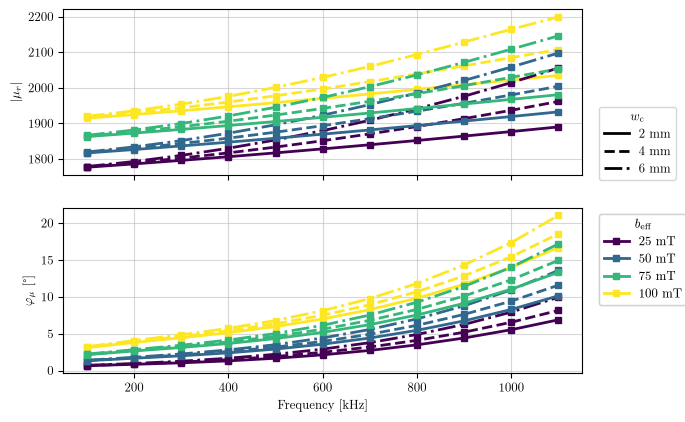

In [30]:
# Combined Bode-style plot: magnitude and phase vs frequency (shared x-axis)
fig, (ax_mag, ax_phase) = plt.subplots(
    2, 1,
    figsize=(17 / 2.54, 12 / 2.54),
    sharex=True
)

# Top: |Z|
mag_settings = PlotSettings(
    x_scale="linear",      # change to "log" if desired
    y_scale="linear",
    show_grid=True,
    grid_which="both",
    grid_alpha=0.5,
    marker="s",
    marker_size=4,
    line_width=2.0,
    color_map_name="viridis",
    line_styles=("-", "--", "-.", ":"),
    show_color_legend=False,
    show_style_legend=True,
    use_tight_layout=False,
    show_title=False,
)
dp.y_over_x_with_color_and_style(
    ax_mag,
    y_col="mu_r_abs",
    x_col="freq",
    color_col="b_mean",
    style_col="w",
    settings=mag_settings,
    text_overrides=PlotTextOverrides(
        x_label="Frequency",
        x_unit="kHz",
        y_label=r"$|\mu_r|$",
        y_unit="",
        color_label=r"$b_\mathrm{eff}$",
        color_unit="mT",
        style_label=r"$w_\mathrm{c}$",
        style_unit="mm",
    ),
)

# Bottom: phase
phase_settings = PlotSettings(
    x_scale="linear",
    y_scale="linear",
    show_grid=True,
    grid_which="both",
    grid_alpha=0.5,
    marker="s",
    marker_size=4,
    line_width=2.0,
    color_map_name="viridis",
    line_styles=("-", "--", "-.", ":"),
    show_color_legend=True,
    show_style_legend=False,
    use_tight_layout=False,
    show_title=False,
)
dp.y_over_x_with_color_and_style(
    ax_phase,
    y_col="mu_r_phase",
    x_col="freq",
    color_col="b_mean",
    style_col="w",
    settings=phase_settings,
    text_overrides=PlotTextOverrides(
        x_label="Frequency",
        x_unit="kHz",
        y_label=r"$\varphi_\mathrm{\mu}$",
        y_unit="°",
        color_label=r"$b_\mathrm{eff}$",
        color_unit="mT",
        style_label=r"$w_\mathrm{c}$",
        style_unit="mm",
    ),
)

# Ensure visual shared-x behavior
ax_mag.tick_params(axis="x", which="both", labelbottom=False)
ax_mag.set_xlabel("")

# fig.tight_layout()

plt.savefig("toroid_mu_complex.pdf", bbox_inches="tight")
plt.show()

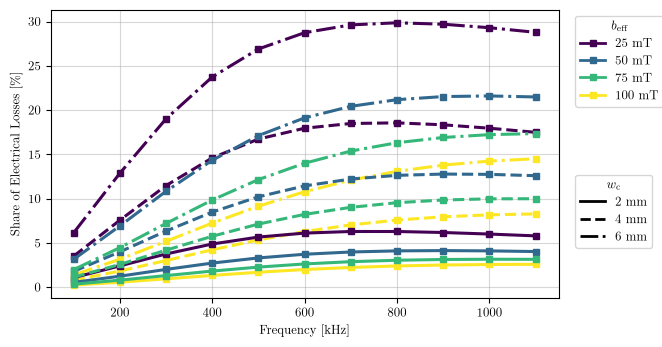

In [32]:
fig, ax = plt.subplots(figsize=(17 / 2.54, 9 / 2.54))  

custom_settings = PlotSettings(
    x_scale="linear",
    y_scale="linear",
    show_grid=True,
    grid_which="both",
    grid_alpha=0.5,
    marker="s",
    marker_size=5,
    line_width=2.2,
    color_map_name="viridis",
    line_styles=("-", "--", "-.", ":"),
    show_color_legend=True,
    show_style_legend=True,
    use_tight_layout=True,
    show_title=False
)

dp.y_over_x_with_color_and_style(
    ax,
    y_col="rel_p_el",
    x_col="freq",
    color_col="b_mean",
    style_col="w",
    settings=custom_settings,
    text_overrides=PlotTextOverrides(
        x_label="Frequency",
        x_unit="kHz",
        y_label="Share of Electrical Losses",
        y_unit=r"\%",
        color_label=r"$b_\mathrm{eff}$",
        color_unit="mT",
        style_label=r"$w_\mathrm{c}$",
        style_unit="mm"
    )
)

plt.savefig(f"toroid_share_of_electrical_losses.pdf", bbox_inches='tight')
plt.show()

### Field Plots

In [33]:
# Choose a geometry index to read the corresponding exported field data
sub_folder="Fields in Cross-Section"

# description, field_display_symbol, field_display_unit, field_scale_factor = "Electric Field", r"$e$", "V/m", 1
description, field_display_symbol, field_display_unit, field_scale_factor = "Magnetic Flux Density", r"$b$", "mT", 1e3

# Set filters
list_of_b = [50]
list_of_freq = [100, 500, 1000]
internal_filter_pairs = [(b, f) for b in list_of_b for f in list_of_freq]
list_of_col_labels = [r"$b_\mathrm{eff}=$" + f" {b} mT\n" + r"$f=$" + f"{f} kHz" for b, f in internal_filter_pairs]

Geometry index: 2 with parameters: {'d_o': 22}


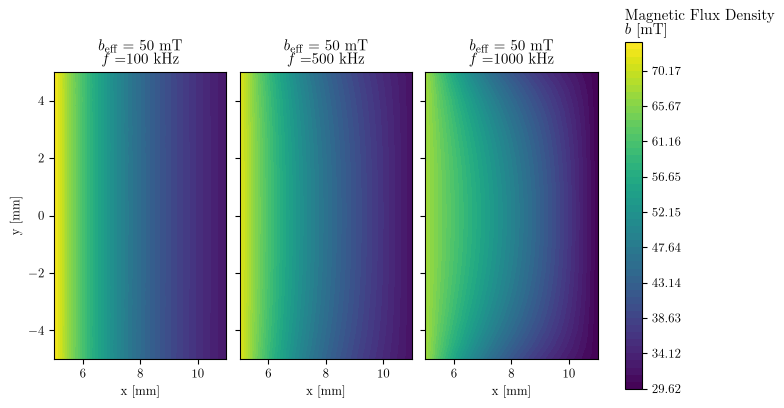

In [34]:
# 1) Select geometry by input-parameter filter
geom_filter = {"d_o": 22}
geometry_idx = get_geometry_idx_from_filter(dp.input_df, geom_filter)
print(f"Geometry index: {geometry_idx} with parameters: {geom_filter}")

# 2) Load the geometry DataFrame that contains the selected field data for the selected geometry index
df_geo, length_unit = read_fields_on_geometry(
    sub_folder, description, geometry_idx, target_length_unit="mm"
)
# Scale the field columns to the desired display unit (e.g., mT instead of T)
df_geo = scale_field_columns(df_geo, scale_factor=field_scale_factor)

# 3) Select internal indices for material/excitation/frequency
# Get indices in that pair order (one query per pair)
list_internal_idx = [
    get_internal_idx_from_filters(
        dp.combined_df,
        geometry_idx,
        {"b_mean": [b], "freq": [f]},
    )[0]
    for b, f in internal_filter_pairs
]

# 4) Plot the selected fields side by side with a shared color scale
list_of_col_names = get_list_of_col_names(df_geo, list_internal_idx)

fig, axes, cbar = plot_row_of_fields(
    df=df_geo,
    list_of_col_names=list_of_col_names,
    list_of_labels=list_of_col_labels,
    field_name=description,
    field_symbol=field_display_symbol,
    field_unit=field_display_unit,
    length_unit=length_unit,
    figsize=(7, 4),
)

plt.show()

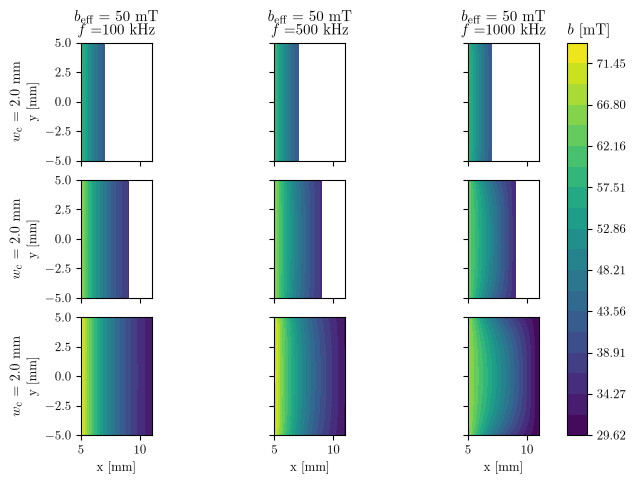

In [35]:
# Example: combined plot for 3 geometry cases (width variations)
d_o_selection = [14, 18, 22]  # mm

list_of_dfs = []
list_of_row_labels = []
list_of_value_cols_per_row = []

# Iterate over the selected geometries 
# and read the corresponding field data
for d_o in d_o_selection:
    # 1) Select geometry idx by input-parameter filter
    geometry_idx = get_geometry_idx_from_filter(dp.input_df, {"d_o": d_o})

    # 2) Load the geometry DataFrame that contains the selected field data for the selected geometry index
    df_geo, length_unit = read_fields_on_geometry(
        sub_folder, description, geometry_idx, target_length_unit="mm"
    )
    # Scale the field columns to the desired display unit (e.g., mT instead of T)
    df_geo = scale_field_columns(df_geo, scale_factor=field_scale_factor)

    # 3) Select internal indices for material/excitation/frequency
    # Get indices in that pair order (one query per pair)
    list_internal_idx = [
        get_internal_idx_from_filters(
            dp.combined_df,
            geometry_idx,
            {"b_mean": [b], "freq": [f]},
        )[0]
        for b, f in internal_filter_pairs
    ]
    list_of_col_names = get_list_of_col_names(df_geo, list_internal_idx)

    # Further processing for combined plots
    list_of_dfs.append(df_geo)
    w = get_geom_param_from_idx(dp.combined_df, geometry_idx, "w")
    list_of_row_labels.append(r"$w_\mathrm{c}$" + f" = {w} mm")
    list_of_value_cols_per_row.append(list_of_col_names)


# 5) Combine all geometries in a unified plot
fig, axes, cbars = plot_grid_of_fields(
    list_of_dfs=list_of_dfs,
    list_of_row_labels=list_of_row_labels,
    list_of_value_cols=list_of_value_cols_per_row,
    list_of_col_labels=list_of_col_labels,
    field_symbol=field_display_symbol,
    field_unit=field_display_unit,
    length_unit=length_unit,
    figsize=(17/2.54, 12/2.54),
    levels=20,
    normalize_mode="global"
)

plt.savefig(f"toroid_{description.replace(' ', '_')}.pdf", bbox_inches='tight')
plt.show()